# Test en Machine Learning
## Prétraitement de données

### 1- faites les importations des bibliothèques nécessaires

In [ ]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
#test
#test2

### 2- importer les données du fichier "dataset_ProjetML_2026.csv"

In [10]:
df = pd.read_csv("dataset_ProjetML_2026.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### 3- afficher un échontillon du dataframe

In [3]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


### 4- afficher toutes les variables du dataset et leurs types respectifs

In [4]:
df.dtypes

Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie            object
Source               object
Rapport_Collecte     object
dtype: object

### 5-Afficher le nombre de lignes et de colonnes du dataframe

In [5]:
df.shape
print("nombre de lignes:",df.shape[0])
print("nombre de colonnes:",df.shape[1])

nombre de lignes: 10500
nombre de colonnes: 9


In [6]:
df['Categorie'].value_counts()

Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [7]:
df['Source'].value_counts()

Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64

### 6- Quelles sont les colonnes qui  contiennent des valeurs nulls ? Endéduire le nombre de valeurs nulls

In [9]:
print(df.isna().sum())

Poids               1029
Volume               540
Conductivite        1017
Opacite             1035
Rigidite             558
Prix_Revente         536
Categorie            514
Source               536
Rapport_Collecte       0
dtype: int64


### 7-remplacer les valeurs manquantes dans la colonne "" par la moyenne de la colonne

In [64]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

In [65]:
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

In [66]:
print(df.isna().sum())

Poids                 0
Volume                0
Conductivite          0
Opacite               0
Rigidite              0
Prix_Revente          0
Categorie           514
Source              536
Rapport_Collecte      0
dtype: int64


### Catégorielle

In [67]:
print(df["Categorie"].mode())
print(df["Source"].mode())


0    Plastique
Name: Categorie, dtype: object
0    Collecte_Citoyenne
Name: Source, dtype: object


In [68]:
cat_cols = df.select_dtypes(include=['object']).columns


In [69]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [70]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
dtype: int64


### 9- Sachant que la colonne "" est la cible, déduire si le dataset est équilibré ou non?

In [17]:
df["Categorie"].value_counts()

Categorie
Plastique    3309
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [46]:
#OUI la dataset est globalement équilibré car Les classes ne sont pas très éloignées

### 10- supprimer la colonne "" du dataset

In [18]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

### 11- Chercher les colonnes qui ont des valeurs abbérantes en affichant le boxplot pour tout le dataset

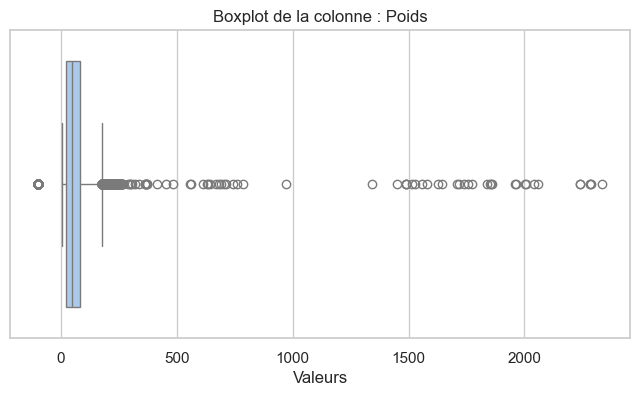

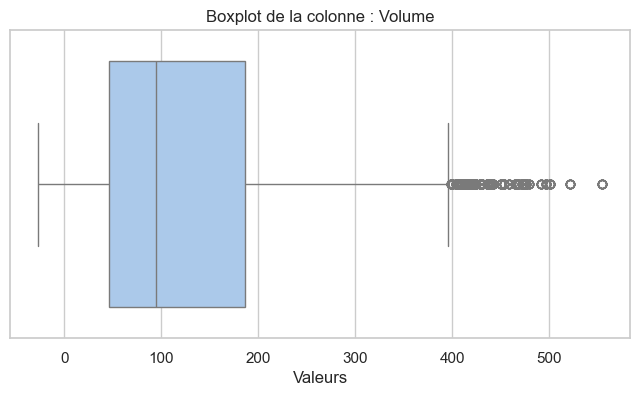

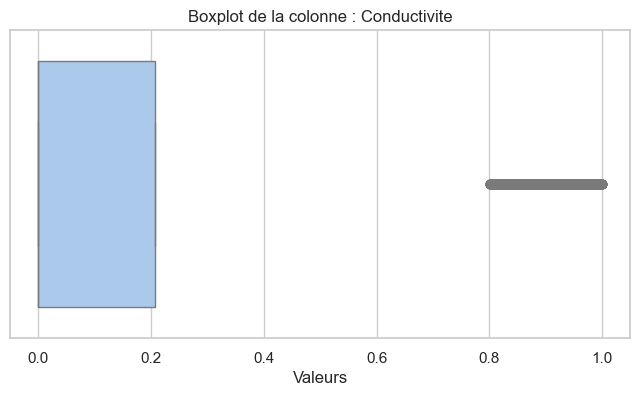

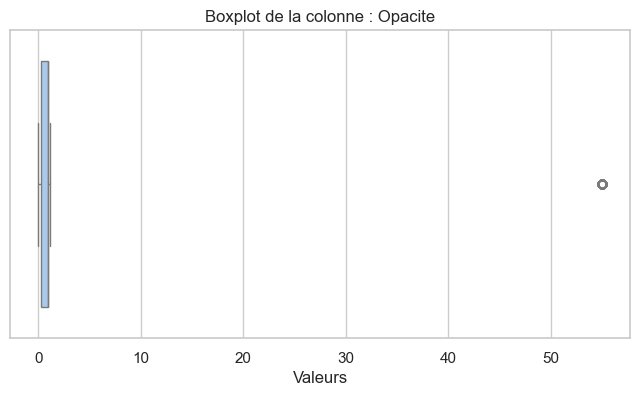

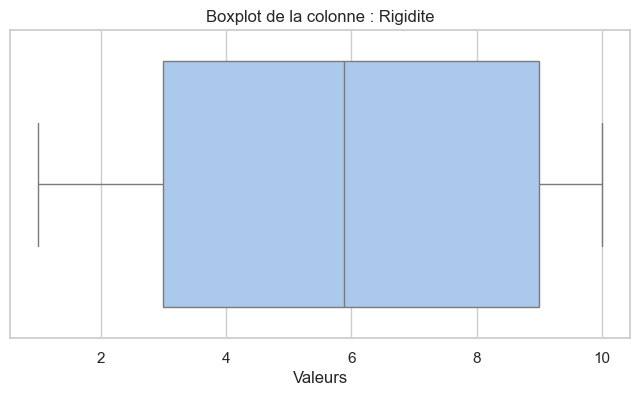

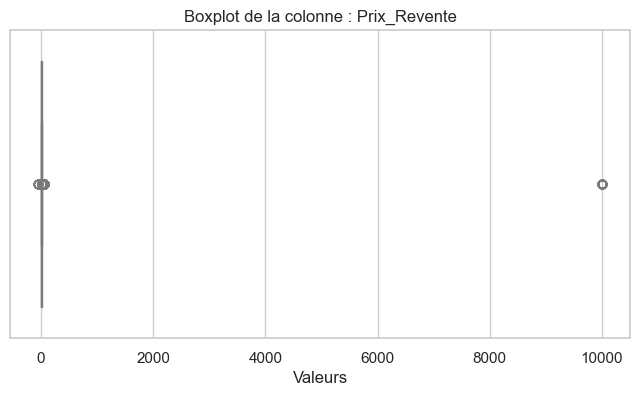

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.set(style='whitegrid')
for col in numeric_cols:
 plt.figure(figsize=(8, 4)) # Ajuster la taille de chaque figure
 sns.boxplot(data=df, x=col, orient='h', palette='pastel') # Boxplot horizontal
 plt.title(f"Boxplot de la colonne : {col}")
 plt.xlabel("Valeurs")
 plt.show()

In [ ]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


### 12- Nous allons traiter les valeurs abbérantes que la colonne "" en remplaçant ces valeurs par la médiane

#### a-calculer les 4 quartiles (Q1,Q3,IRQ) et Sup, Inf

In [20]:
Q1 = df["Poids"].quantile(0.25)
Q3 = df["Poids"].quantile(0.75)
IQR = Q3 - Q1

inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR


#### b-remplacer les VA par la mediane de la colonne

In [37]:
outliers = df[(df['Poids'] < inf) | (df['Poids'] > sup)]
print(outliers)
for i in df['Poids']:
    if i >=sup or i<=inf:
        df['Poids']=df['Poids'].replace(i,np.median(df['Poids']))

Empty DataFrame
Columns: [Poids, Volume, Conductivite, Opacite, Rigidite, Prix_Revente, Categorie, Source, Rapport_Collecte]
Index: []


#### c-vérifier la modification des VA

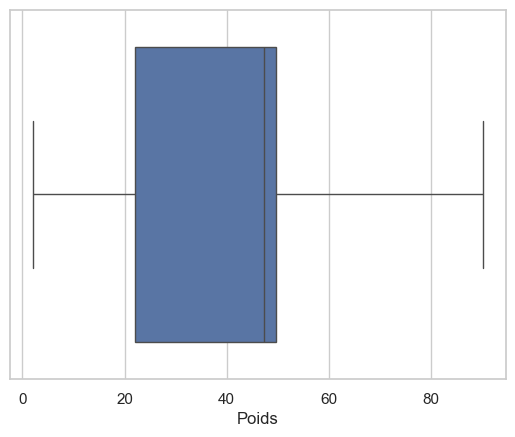

In [39]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Poids'] ,orient='h')

### 13- supprimer les VA de la colonne ''

In [46]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Volume'] >= inf) & (df['Volume'] <= sup)]


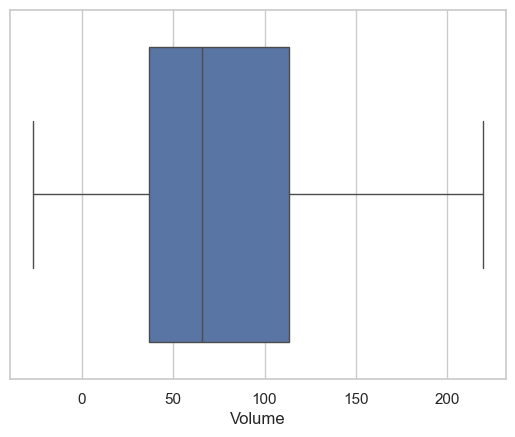

In [47]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Volume'] ,orient='h')

### *13- Traiter les VA de la colonne 

In [48]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


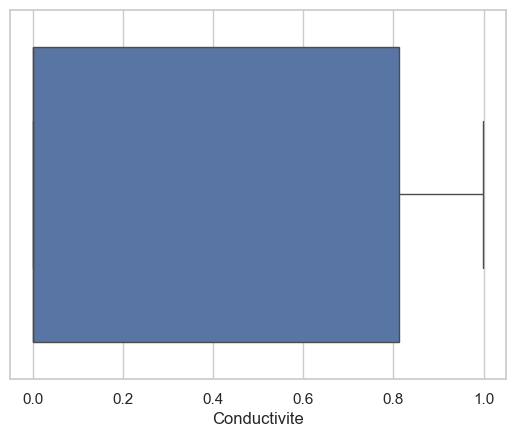

In [49]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Conductivite'] ,orient='h')

In [54]:
Q1 = df['Prix_Revente'].quantile(0.25)
Q3 = df['Prix_Revente'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Prix_Revente'] >= inf) & (df['Prix_Revente'] <= sup)]


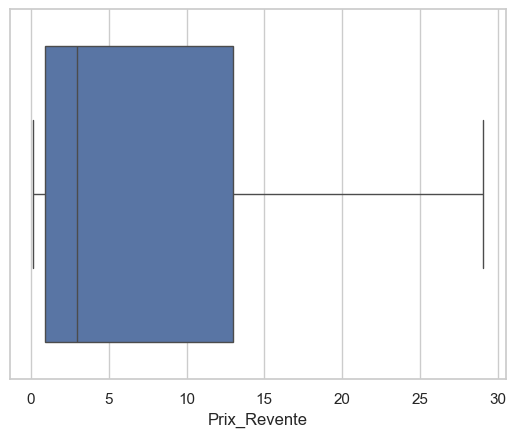

In [55]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Prix_Revente'] ,orient='h')

### 14- affecter à Y (cible) la dernière colonne () et le reste du dataframe au entrées X

In [72]:
Y_class = df['Categorie']
X_class = df.drop(['Categorie', 'Rapport_Collecte'], axis=1)  # garde le DataFrame (pas .values)
print("Cible Y :")
print(Y_class)
print("\nEntrées X :")
print(X_class)

Cible Y :
0           Papier
1        Plastique
2            Verre
3           Papier
4           Papier
           ...    
10495        Verre
10496        Verre
10497       Papier
10498    Plastique
10499        Verre
Name: Categorie, Length: 10500, dtype: object

Entrées X :
            Poids      Volume  Conductivite   Opacite   Rigidite  \
0       16.708780   70.940977           0.0  1.000000   1.000000   
1       47.277476   64.702925           0.0  1.160388   3.000000   
2       77.796501  317.415183           0.0  1.160388   9.000000   
3       77.796501   21.474391           0.0  1.160388   1.000000   
4       77.796501   59.462176           0.0  1.000000   5.886643   
...           ...         ...           ...       ...        ...   
10495  191.018619  418.800912           0.0  0.019307   9.000000   
10496  149.052713  287.519460           0.0  0.157940  10.000000   
10497   15.572667   50.148243           0.0  1.000000   2.000000   
10498   26.707263   44.008897           0.

### 15- afficher un echontillion de X et Y

In [73]:
print('Echantillon de X :')
print(X_class.iloc[np.random.choice(len(X_class), 5)])
print('\nEchantillon de Y :')
print(Y_class.iloc[np.random.choice(len(Y_class), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
3113   61.713415  126.432865      0.885043  1.000000       9.0     18.514024   
8208   63.158520  143.922964      0.923321  1.000000       9.0     18.947556   
3507   10.489569   42.191996      0.000000  1.000000       2.0      0.524478   
601    29.936484   91.118072      0.000000  0.204841       4.0      2.993648   
1416  157.925883  319.925207      0.207674  0.176483      10.0      4.737776   

                  Source  
3113             Usine_A  
8208             Usine_A  
3507  Collecte_Citoyenne  
601   Collecte_Citoyenne  
1416             Usine_A  

Echantillon de Y :
7751         Verre
2044     Plastique
9090     Plastique
3995         Verre
10034        Verre
Name: Categorie, dtype: object


In [74]:
# Encoder la cible Y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_class = le.fit_transform(Y_class.astype(str))  # astype(str) gère les NaN

In [75]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Trouver l'index de 'Source' dans X_class
source_idx = X_class.columns.get_loc('Source')

ct = ColumnTransformer(
    [('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [source_idx])],
    remainder='passthrough'
)
X_class = ct.fit_transform(X_class)

In [76]:
X_class = np.array(X_class, dtype=float)
Y_class = np.array(Y_class)

print("Shape de X après encodage :", X_class.shape)
print("Shape de Y :", Y_class.shape)

Shape de X après encodage : (10500, 10)
Shape de Y : (10500,)


In [77]:
X_class[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 8.35438994e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 1.16038817e+00,
        3.00000000e+00, 4.72774763e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        7.77965008e+01, 3.17415183e+02, 0.00000000e+00, 1.16038817e+00,
        9.00000000e+00, 4.21179011e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        7.77965008e+01, 2.14743907e+01, 0.00000000e+00, 1.16038817e+00,
        1.00000000e+00, 4.42067308e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        7.77965008e+01, 5.94621756e+01, 0.00000000e+00, 1.00000000e+00,
        5.88664253e+00, 7.23003759e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
   

In [78]:
Y_class

array([1, 2, 3, ..., 1, 2, 3])

### 16- Transformer X et Y en tableau numpy

### 17- transformer les colonnes catégoriques "", "" et "" en numérique

### 18- Vérifier cette transformation

### 19- Subdiviser la dataset en deux parties train et test

In [79]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_class, Y_class, test_size=0.2, random_state=0
)

print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('y_train mean:', y_train.mean())
print('y_test mean:', y_test.mean())

x_train: (8400, 10)
x_test: (2100, 10)
y_train: (8400,)
y_test: (2100,)
y_train mean: 1.5907142857142857
y_test mean: 1.5866666666666667


### 20- Mettre à l'échelle par standardisation les variables en entrée X_train et X_test

In [80]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


# Modélisation KNN et évaluation

In [58]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 3)

knn.fit(x_train,y_train)

y_pred_knn = knn.predict(x_test)


import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report
print("Nombre de NaN dans Y_test:", np.isnan(y_test).sum())
print("Nombre de NaN dans y_pred_knn:", np.isnan(y_pred_knn).sum())
if np.isnan(y_test).sum() > 0 or np.isnan(y_pred_knn).sum() > 0:
    y_test = np.nan_to_num(y_test, nan=0)  
    y_pred_knn = np.nan_to_num(y_pred_knn, nan=0) 
print('Confusion matrix knn \n', confusion_matrix(y_test, y_pred_knn))
print('Accuracy knn:', accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print('Recall knn:', recall_score(y_test, y_pred_knn, average='binary'))
print('Precision knn:', precision_score(y_test, y_pred_knn, average='binary'))
for i in range(10):
    print("Vérité terrain:", y_test[i], "Prédiction:", y_pred_knn[i])

Nombre de NaN dans Y_test: 0
Nombre de NaN dans y_pred_knn: 0
Confusion matrix knn 
 [[ 966  759]
 [ 574 2446]]
Accuracy knn: 0.719072708113804
              precision    recall  f1-score   support

         0.0       0.63      0.56      0.59      1725
         1.0       0.76      0.81      0.79      3020

    accuracy                           0.72      4745
   macro avg       0.70      0.68      0.69      4745
weighted avg       0.71      0.72      0.72      4745

Recall knn: 0.8099337748344371
Precision knn: 0.763182527301092
Vérité terrain: 1.0 Prédiction: 1.0
Vérité terrain: 1.0 Prédiction: 1.0
Vérité terrain: 1.0 Prédiction: 1.0
Vérité terrain: 1.0 Prédiction: 1.0
Vérité terrain: 1.0 Prédiction: 1.0
Vérité terrain: 0.0 Prédiction: 0.0
Vérité terrain: 0.0 Prédiction: 0.0
Vérité terrain: 0.0 Prédiction: 0.0
Vérité terrain: 1.0 Prédiction: 1.0
Vérité terrain: 1.0 Prédiction: 1.0


# Mdélisation Grid Search et évaluation

In [59]:
from sklearn.model_selection import GridSearchCV
parameters = {'n_neighbors' : [1,3,5,7,9,11,13]}
model = KNeighborsClassifier()
clf = GridSearchCV(model,parameters, scoring='recall', cv=5)
grille = clf.fit(x_train,y_train)
# meilleur paramètre et meilleur score qui est l'accuracy
print(grille.best_params_)
print(grille.best_score_)

y_pred_knn_o = grille.predict(x_test)

knn_op_acc=accuracy_score(y_test,y_pred_knn_o)
knn_op_rec=recall_score(y_test,y_pred_knn_o)
knn_op_prec=precision_score(y_test,y_pred_knn_o)
print('Confusion matrix knn op \n', confusion_matrix(y_test,y_pred_knn_o))
print('Accuracy knn op', knn_op_acc)
print('Recall knn op', knn_op_rec)
print('Precision knn op',knn_op_prec)


{'n_neighbors': 13}
0.8608456198806053
Confusion matrix knn op 
 [[ 927  798]
 [ 403 2617]]
Accuracy knn op 0.7468914646996839
Recall knn op 0.8665562913907284
Precision knn op 0.766325036603221


# Decision Tree

In [60]:
import graphviz
from sklearn import tree
from sklearn.tree import export_graphviz
from sklearn.tree import DecisionTreeClassifier
dt= DecisionTreeClassifier()
model = DecisionTreeClassifier(max_depth = 5)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [61]:
features=['Diagnosed_Condition', 'Patient_Age', 'BMI', 'Smoker', 'Residence',
       'mental_condition', 'Number_of_prev_cond']
tree.export_graphviz(model,feature_names = features,\
                    out_file = 'dt_tree.dot',\
                    label = 'all',\
                    filled = True,\
                    rounded = True)

In [62]:
!pip install graphviz

In [63]:
!dot -Tpng dt_tree.dot -o dt_tree.png

'dot' n'est pas reconnu en tant que commande interne
ou externe, un programme ex‚cutable ou un fichier de commandes.


In [88]:
from sklearn.tree import DecisionTreeClassifier
dt= DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred_dt= dt.predict(x_test)
for i in range(10):
        print('Confusion matrix dt\n', confusion_matrix(y_test,y_pred_dt))
        print('Accuracydt', accuracy_score(y_test,y_pred_dt))
        print('Recalldt', recall_score(y_test,y_pred_dt))
        print('Precisiondt', precision_score(y_test,y_pred_dt))
        print(classification_report(y_test,y_pred_dt))
accur_dt=accuracy_score(y_test,y_pred_dt)
rec_dt=recall_score(y_test,y_pred_dt)
pres_dt=precision_score(y_test,y_pred_dt)


Confusion matrix dt
 [[1018  707]
 [ 735 2285]]
Accuracydt 0.6961011591148577
Recalldt 0.7566225165562914
Precisiondt 0.7637032085561497
              precision    recall  f1-score   support

         0.0       0.58      0.59      0.59      1725
         1.0       0.76      0.76      0.76      3020

    accuracy                           0.70      4745
   macro avg       0.67      0.67      0.67      4745
weighted avg       0.70      0.70      0.70      4745

Confusion matrix dt
 [[1018  707]
 [ 735 2285]]
Accuracydt 0.6961011591148577
Recalldt 0.7566225165562914
Precisiondt 0.7637032085561497
              precision    recall  f1-score   support

         0.0       0.58      0.59      0.59      1725
         1.0       0.76      0.76      0.76      3020

    accuracy                           0.70      4745
   macro avg       0.67      0.67      0.67      4745
weighted avg       0.70      0.70      0.70      4745

Confusion matrix dt
 [[1018  707]
 [ 735 2285]]
Accuracydt 0.69610115911

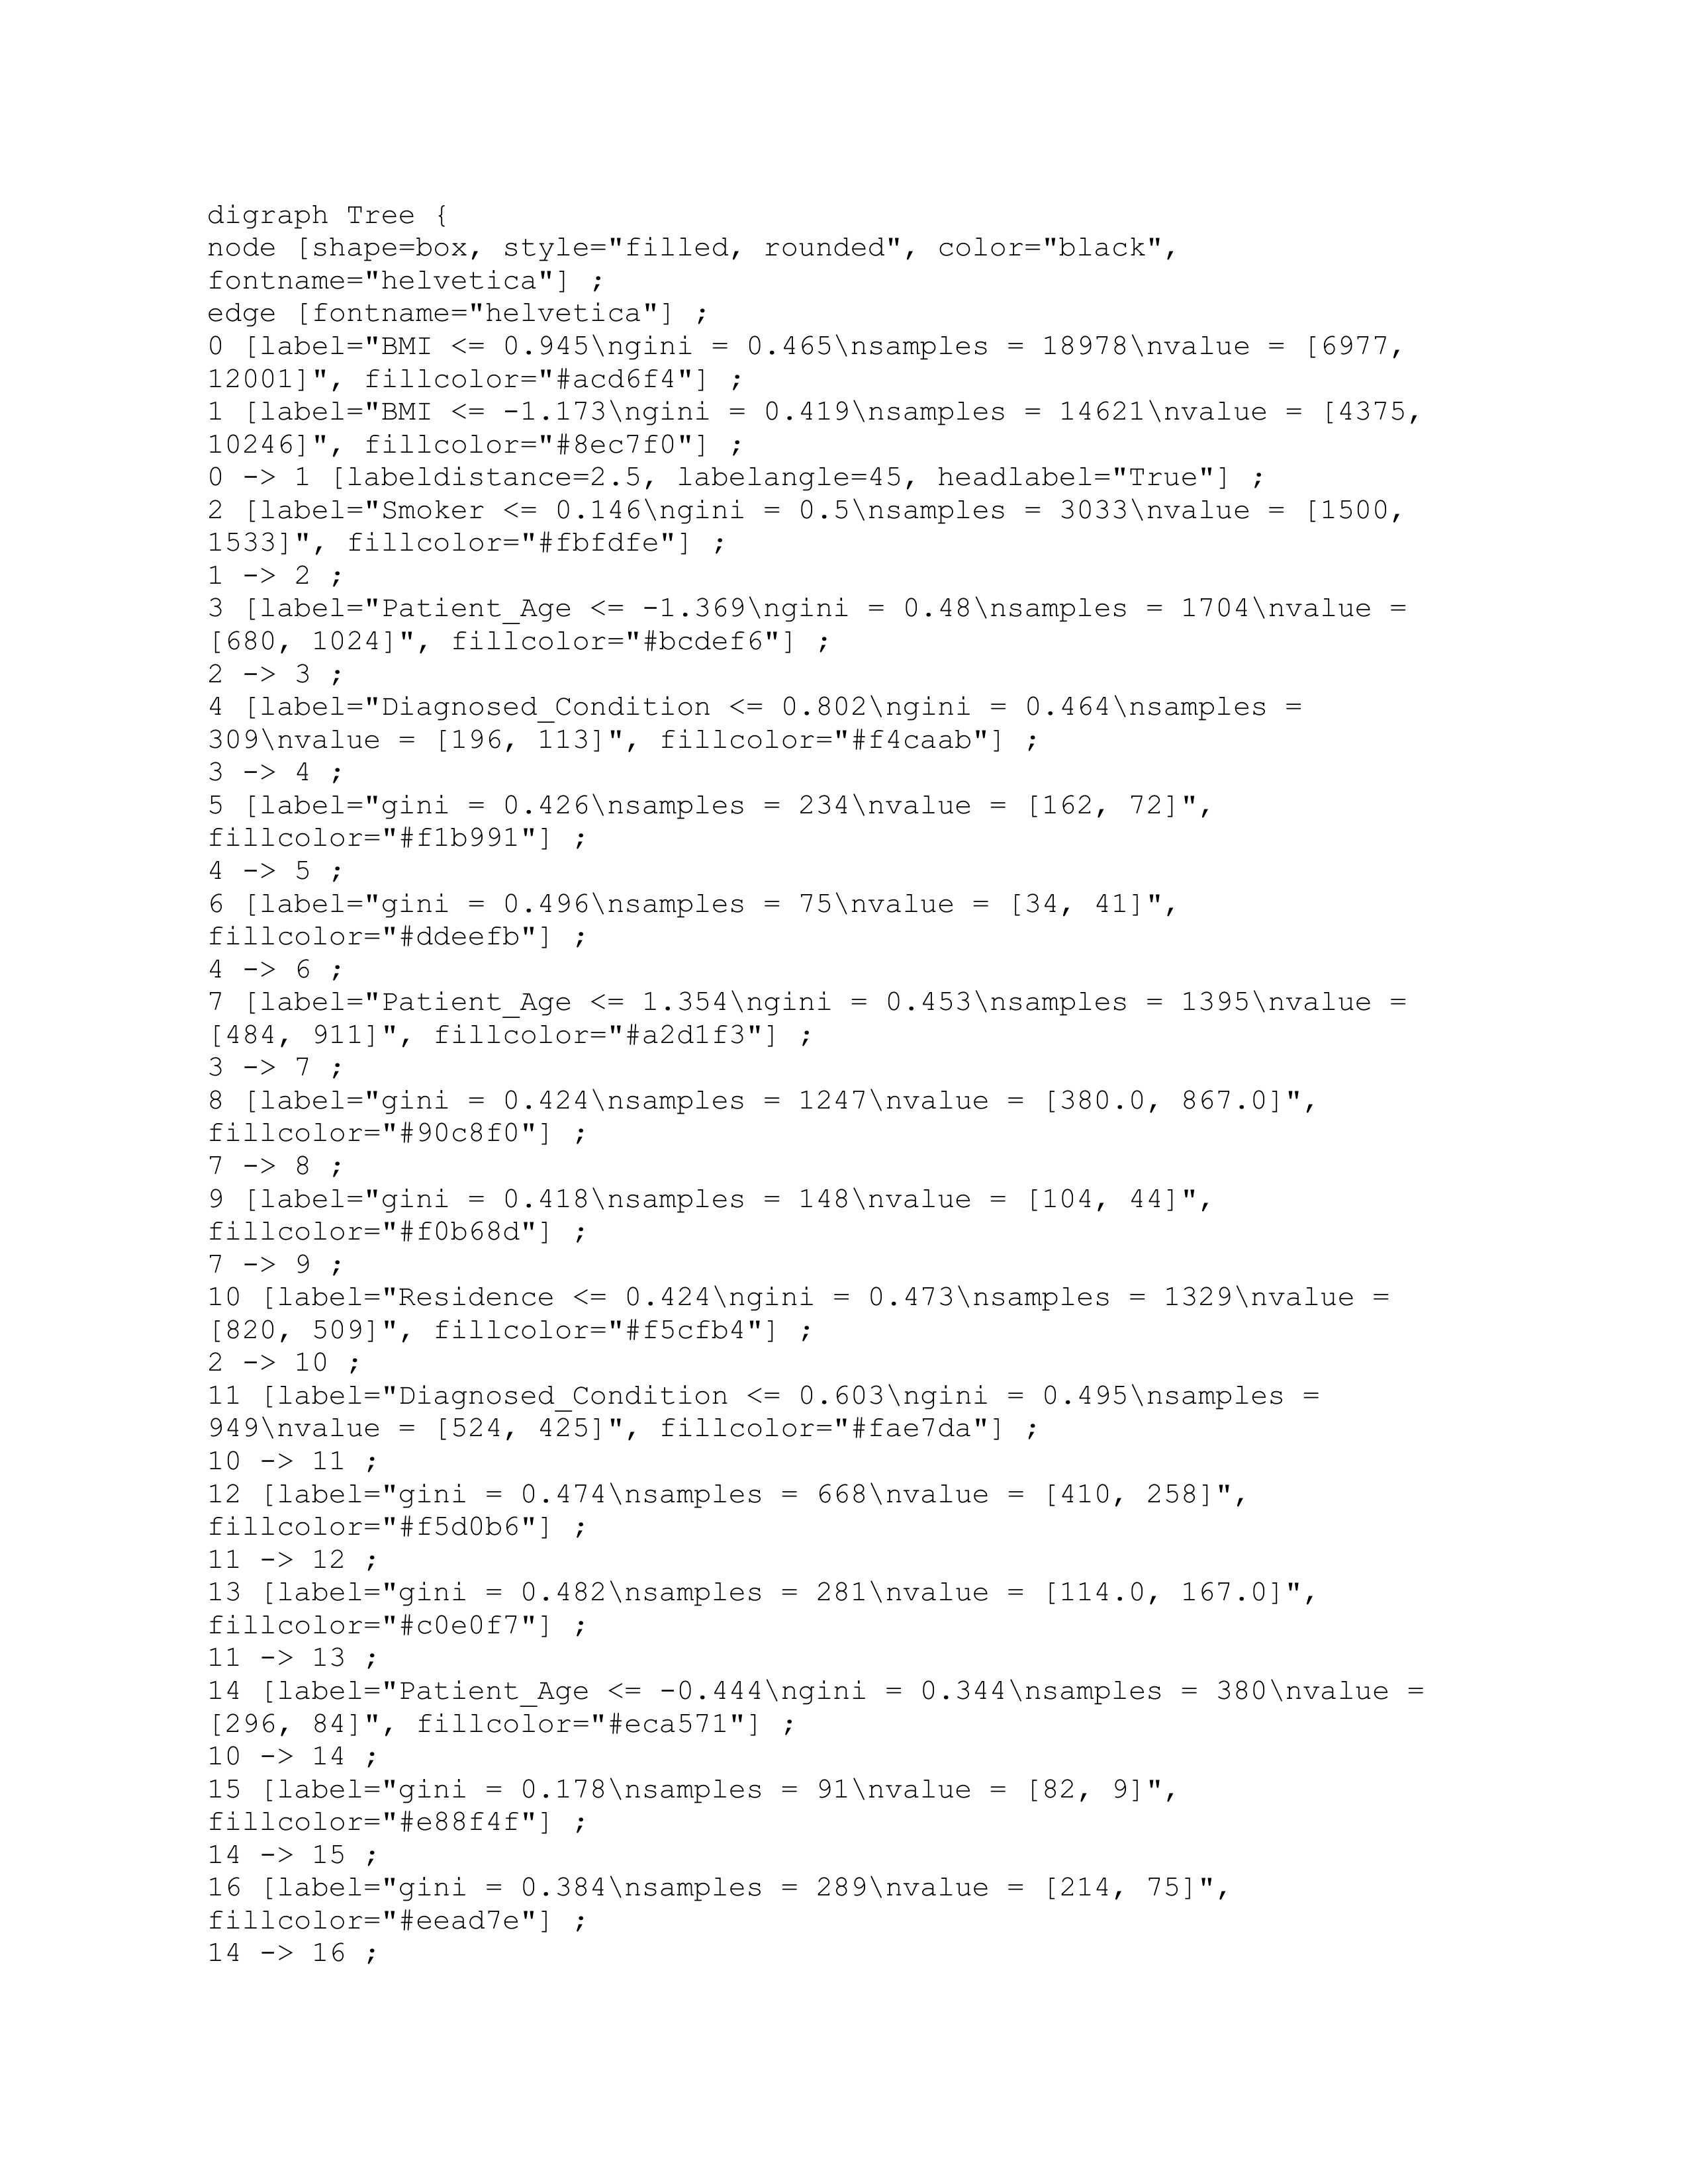

In [65]:
from IPython.display import Image
Image('dt_tree.png')

In [66]:
!pip install graphviz


# Random Forest

## Importance des features

In [91]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500)
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
print('Confusion matrix rf \n', confusion_matrix(y_test,y_pred_rf))
print('Accuracy rf', accuracy_score(y_test,y_pred_rf))
print('Recall rf', recall_score(y_test,y_pred_rf))
print('Precision rf', precision_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))
rf_acc=accuracy_score(y_test,y_pred_rf)
rf_rec= recall_score(y_test,y_pred_rf)
rf_prec=precision_score(y_test,y_pred_rf)

Confusion matrix rf 
 [[1033  692]
 [ 445 2575]]
Accuracy rf 0.7603793466807165
Recall rf 0.8526490066225165
Precision rf 0.78818487909397
              precision    recall  f1-score   support

         0.0       0.70      0.60      0.65      1725
         1.0       0.79      0.85      0.82      3020

    accuracy                           0.76      4745
   macro avg       0.74      0.73      0.73      4745
weighted avg       0.76      0.76      0.76      4745



In [68]:
importances = rf.feature_importances_

In [69]:
importances

array([0.26419874, 0.22384294, 0.37165519, 0.06800079, 0.02468917,
       0.        , 0.04761316])

In [70]:
# retourn l'indice des valeur triées
sorted_idx = np.argsort(importances)

In [71]:
features_arr = np.asarray(features)

Text(0.5, 1.0, 'Variable importance')

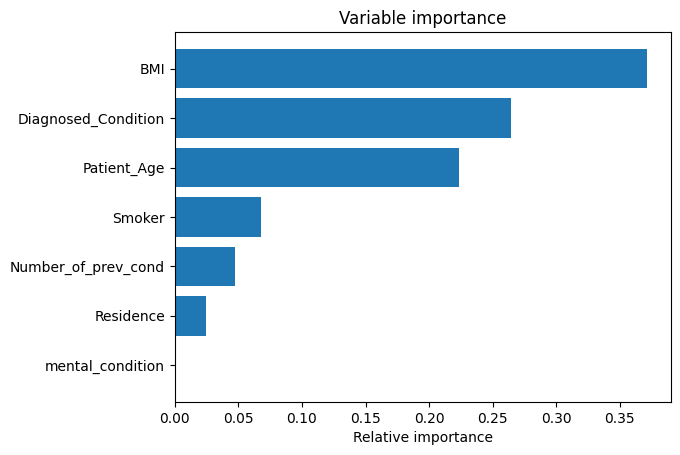

In [72]:
# espace entre les différentes barres
padding=np.arange(x_train.size/len(x_train))
plt.barh(padding,importances[sorted_idx],align='center')
plt.yticks(padding,features_arr[sorted_idx])
plt.xlabel('Relative importance')
plt.title('Variable importance')

# SVM linéaire

In [73]:
from sklearn.svm import SVC
linear_SVM = SVC(kernel='linear')
linear_SVM.fit(x_train,y_train)
y_predictSVM_l = linear_SVM.predict(x_test)
svm_acc=accuracy_score(y_test,y_predictSVM_l)
svm_prec=precision_score(y_test,y_predictSVM_l)
svm_rec=recall_score(y_test,y_predictSVM_l)
print(confusion_matrix(y_test,y_predictSVM_l))
print('Accuracy linear SVM {0:.3f}'.format(svm_acc))
print('Precision linear SVM {0:.3f}'.format(svm_prec))
print('Recall linear SVM {0:.3f}'.format(svm_rec))
print(classification_report(y_test,y_predictSVM_l))

[[1007  718]
 [1011 2009]]
Accuracy linear SVM 0.636
Precision linear SVM 0.737
Recall linear SVM 0.665
              precision    recall  f1-score   support

         0.0       0.50      0.58      0.54      1725
         1.0       0.74      0.67      0.70      3020

    accuracy                           0.64      4745
   macro avg       0.62      0.62      0.62      4745
weighted avg       0.65      0.64      0.64      4745



# SVM Kernel

MovieWriter imagemagick unavailable; using Pillow instead.


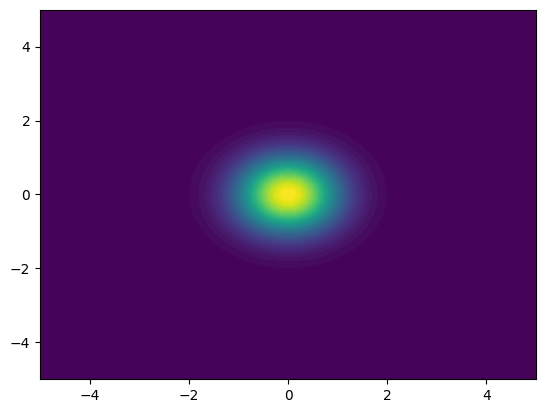

In [74]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
x = np.linspace(-5, 5, 500)
y = np.linspace(-5, 5, 500)
X, Y = np.meshgrid(x, y)
Z = np.exp(-(X**2 + Y**2)) 
fig, ax = plt.subplots()
contour = ax.contourf(X, Y, Z, levels=50, cmap="viridis")
def update(frame):
    global contour  
    for c in contour.collections:
        c.remove()  
    Z_new = np.exp(-(X**2 + Y**2) / (1 + 0.1 * frame)) 
    contour = ax.contourf(X, Y, Z_new, levels=50, cmap="viridis")
    return contour.collections
ani = FuncAnimation(fig, update, frames=20, repeat=True)
ani.save("rbf.gif", writer="imagemagick", fps=5)

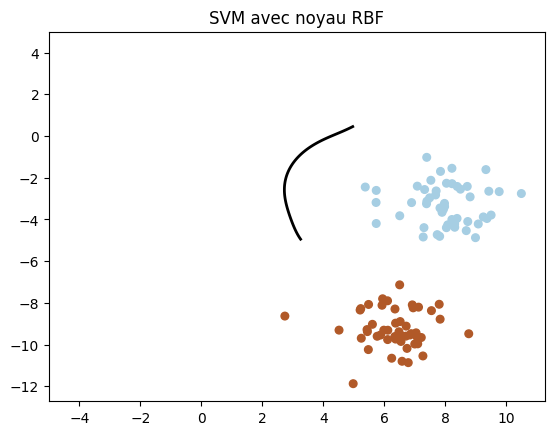

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, centers=2, cluster_std=1.0, random_state=6)
clf = svm.SVC(kernel='rbf', C=1, gamma=0.5)
clf.fit(X, y)
xx, yy = np.meshgrid(np.linspace(-5, 5, 500), np.linspace(-5, 5, 500))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='k') 
plt.title("SVM avec noyau RBF")
plt.savefig("kernel_svm.png")  
plt.show()

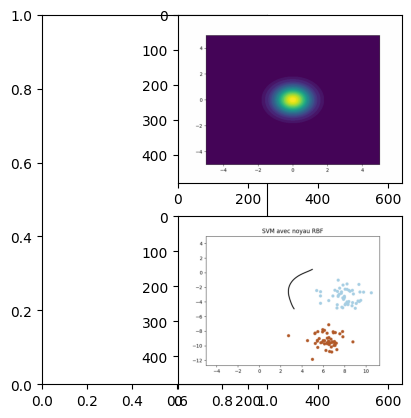

In [76]:
import matplotlib.image as mpimg
fig = plt.figure()
a=fig.add_subplot(1,2,1)
img1 = mpimg.imread('rbf.gif')
img2 = mpimg.imread('kernel_svm.png')
plt.figure(1)
plt.subplot(211)
plt.imshow(img1)

plt.subplot(212)
plt.imshow(img2)
plt.show()


In [77]:
kernel_SVM = SVC(kernel='rbf')
kernel_SVM.fit(x_train,y_train)
y_predictSVM_k = kernel_SVM.predict(x_test)

Ksvm_acc=accuracy_score(y_test,y_predictSVM_k)
Ksvm_rec=precision_score(y_test,y_predictSVM_k)
Ksvm_prec=recall_score(y_test,y_predictSVM_k)
print(confusion_matrix(y_test,y_predictSVM_k))
print('Accuracy rbf SVM {0:.3f}'.format(Ksvm_acc))
print('Precision rbf SVM {0:.3f}'.format(Ksvm_rec))
print('Recall rbf SVM {0:.3f}'.format(Ksvm_prec))

[[ 822  903]
 [ 297 2723]]
Accuracy rbf SVM 0.747
Precision rbf SVM 0.751
Recall rbf SVM 0.902


In [78]:
print(classification_report(y_test,y_predictSVM_k))

              precision    recall  f1-score   support

         0.0       0.73      0.48      0.58      1725
         1.0       0.75      0.90      0.82      3020

    accuracy                           0.75      4745
   macro avg       0.74      0.69      0.70      4745
weighted avg       0.75      0.75      0.73      4745



# Logistic Regression

In [79]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [80]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

y_predictLR = LR.predict(x_test)

LR_acc=accuracy_score(y_test,y_predictLR)
LR_prec=metrics.precision_score(y_test,y_predictLR)
LR_rec=metrics.recall_score(y_test,y_predictLR)
print(confusion_matrix(y_test,y_predictLR))
print('Accuracy Logistic Regression {0:.3f}'.format(LR_acc))
print('Precision Logistic Regression {0:.3f}'.format(LR_prec))
print('Recall Logistic Regression {0:.3f}'.format(LR_rec))

[[ 626 1099]
 [ 376 2644]]
Accuracy Logistic Regression 0.689
Precision Logistic Regression 0.706
Recall Logistic Regression 0.875


# Sommary

In [94]:
print("| Algorithm       | Accuracy     |Recall     | Precision  |")
print("| --------------- | -------------|-----------|------------|")
print("| Optimized kNN   | {0:.3f}        | {0:.3f}     | {0:.3f}      |".format(knn_op_acc,knn_op_rec,knn_op_prec))
print("| Decision Tree   | {0:.3f}        | {0:.3f}     | {0:.3f}      |".format(accur_dt,rec_dt,pres_dt))
print("| Random Forest   | {0:.3f}        | {0:.3f}     | {0:.3f}      |".format(rf_acc, rf_rec, rf_prec))
print("| Linear SVM      | {0:.3f}        | {0:.3f}     | {0:.3f}      |".format(svm_acc,svm_rec,svm_prec))
print("| Kernel SVM      | {0:.3f}        | {0:.3f}     | {0:.3f}      |".format(Ksvm_acc,Ksvm_rec,Ksvm_prec))
print("| Logistic Reg    | {0:.3f}        | {0:.3f}     | {0:.3f}      |".format(LR_acc,LR_rec,LR_prec))

| Algorithm       | Accuracy     |Recall     | Precision  |
| --------------- | -------------|-----------|------------|
| Optimized kNN   | 0.747        | 0.747     | 0.747      |
| Decision Tree   | 0.696        | 0.696     | 0.696      |
| Random Forest   | 0.760        | 0.760     | 0.760      |
| Linear SVM      | 0.636        | 0.636     | 0.636      |
| Kernel SVM      | 0.747        | 0.747     | 0.747      |
| Logistic Reg    | 0.689        | 0.689     | 0.689      |
